# **TCC - PERFIS DE DESEMPENHO NO ENEM(2018–2023) EM MUNICÍPIOS DA ÁREA DE ABRANGÊNCIA DO IFNMG**

Neste segundo notebook, daremos continuidade ao trabalho iniciado na etapa de pré-processamento, onde realizamos a leitura e unificação das bases do ENEM de 2018 a 2023, aplicamos o filtro para as cidades da área de abrangência do IFNMG, removemos colunas desnecessárias, eliminamos registros de candidatos ausentes, renomeamos variáveis do questionário para facilitar a compreensão, tratamos duplicidades e inconsistências de codificação, além de compilar os dados apenas do estado de Minas Gerais e converter variáveis categóricas em ordinais. Assim, a partir dessa base já estruturada e padronizada, avançaremos agora para a etapa de aplicação de métodos estatísticos, buscando extrair interpretações relevantes sobre os candidatos e seus contextos.

Importando as bibliotecas que serão utilizadas.

In [1]:
import os
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

### **Realizando a leitura da base de área de abrangencia do IFNMG**

In [3]:
#Base com dados já convertidos em ordinal
df_final = pd.read_csv("BASES\ENEM_FINAL.csv")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,1.0,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,0.0,0.0,0.0,1.0,1.0,0.0,3.0,0.0,0.0,0.0
1,2018,2,0.0,0.0,3,1,2,2,1.0,São Francisco,...,0.0,0.0,0.0,1.0,1.0,0.0,3.0,0.0,0.0,1.0
2,2018,2,1.0,0.0,3,1,2,2,1.0,Montalvânia,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0
3,2018,3,0.0,0.0,1,1,2,2,1.0,Teófilo Otoni,...,1.0,0.0,0.0,1.0,0.0,1.0,4.0,0.0,1.0,1.0
4,2018,3,1.0,0.0,1,1,2,1,1.0,Januária,...,0.0,0.0,0.0,2.0,1.0,0.0,3.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59749,2023,3,1.0,0.0,3,1,2,2,1.0,Pedra Azul,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
59750,2023,3,0.0,1.0,3,1,2,2,1.0,Montes Claros,...,1.0,0.0,1.0,1.0,0.0,1.0,4.0,0.0,2.0,1.0
59751,2023,4,1.0,1.0,1,1,2,2,NaN,Teófilo Otoni,...,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,1.0
59752,2023,2,1.0,1.0,3,1,2,2,1.0,Montes Claros,...,1.0,0.0,1.0,1.0,1.0,0.0,4.0,1.0,2.0,1.0


### **Realizando a leitura da base de MG**

In [4]:
df_mg = pd.read_csv("BASES/MG.csv")
df_mg

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,M,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,F,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,M,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,F,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,M,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,F,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


### Analise das notas do IFNMG

In [6]:
colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]

estatisticas = pd.DataFrame({
    "Nota Mínima": df_final[colunas_notas].min(),
    "Nota Máxima": df_final[colunas_notas].max(),
    "Nota Média": df_final[colunas_notas].mean()
}).T  

estatisticas = estatisticas.round(1)

estatisticas

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
Nota Mínima,0.0,0.0,0.0,0.0,0.0
Nota Máxima,799.4,846.9,767.3,987.9,1000.0
Nota Média,484.1,522.1,511.1,530.1,570.2


### Analise das notas de MG

In [7]:
colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]

estatisticas = pd.DataFrame({
    "Nota Mínima": df_mg[colunas_notas].min(),
    "Nota Máxima": df_mg[colunas_notas].max(),
    "Nota Média": df_mg[colunas_notas].mean()
}).T  

estatisticas = estatisticas.round(1)

estatisticas

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
Nota Mínima,0.0,0.0,0.0,0.0,0.0
Nota Máxima,869.6,862.6,790.8,996.1,1000.0
Nota Média,509.3,548.2,534.1,568.3,622.5


### Analisando notas 0 para o IFNMG

In [8]:
colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]

# Total de alunos
total = len(df_final)

# Calcular quantidade de zeros e porcentagem
qtd_zeros = (df_final[colunas_notas] == 0).sum()
porcent_zeros = (qtd_zeros / total * 100).round(2).astype(str) + "%"

# Criar DataFrame para exibir
tabela_zeros = pd.DataFrame([qtd_zeros, porcent_zeros], index=["Qtd", "Porcent."])
tabela_zeros

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
Qtd,35,95,42,35,2597
Porcent.,0.06%,0.16%,0.07%,0.06%,4.35%


### Analisando notas 0 para o estado de MG

In [9]:
colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]

# Total de alunos
total = len(df)

# Calcular quantidade de zeros e porcentagem
qtd_zeros = (df_mg[colunas_notas] == 0).sum()
porcent_zeros = (qtd_zeros / total * 100).round(2).astype(str) + "%"

# Criar DataFrame para exibir
tabela_zeros = pd.DataFrame([qtd_zeros, porcent_zeros], index=["Qtd", "Porcent."])
tabela_zeros

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
Qtd,270,539,242,276,11571
Porcent.,0.45%,0.9%,0.4%,0.46%,19.36%


### Gráfico da quantidade de participantes por ano IFNMG.

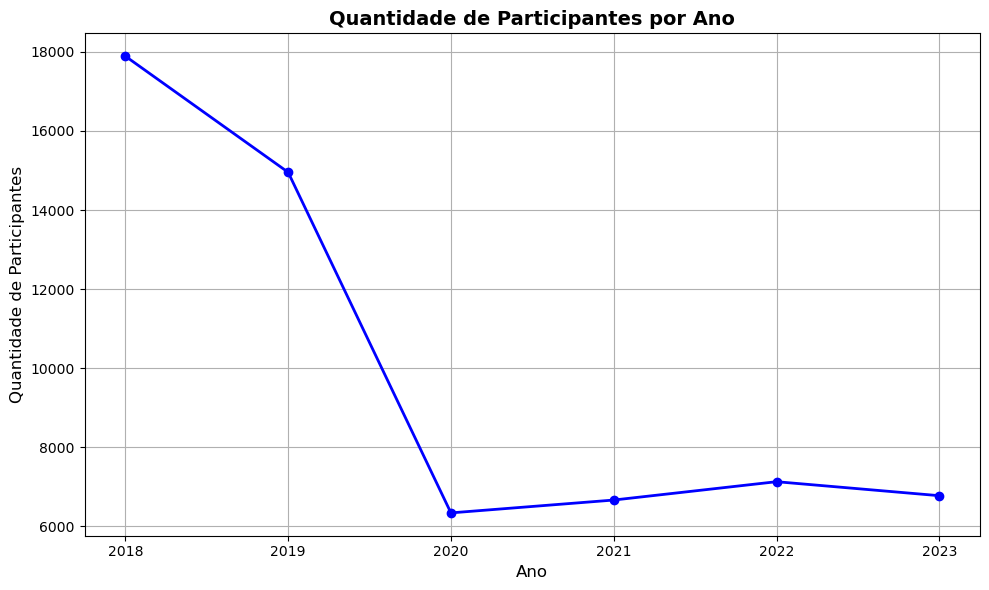

In [10]:
# Agrupar por ano e contar participantes
qtd_por_ano = df_final.groupby("NU_ANO").size().reset_index(name="Quantidade de Participantes")

qtd_por_ano

plt.figure(figsize=(10,6))
plt.plot(qtd_por_ano["NU_ANO"], qtd_por_ano["Quantidade de Participantes"], 
         marker='o', color='blue', linewidth=2)

plt.title("Quantidade de Participantes por Ano", fontsize=14, fontweight='bold')
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Quantidade de Participantes", fontsize=12)
plt.grid(True)
plt.tight_layout()

### Gráfico da quantidade de participantes por ano MG.

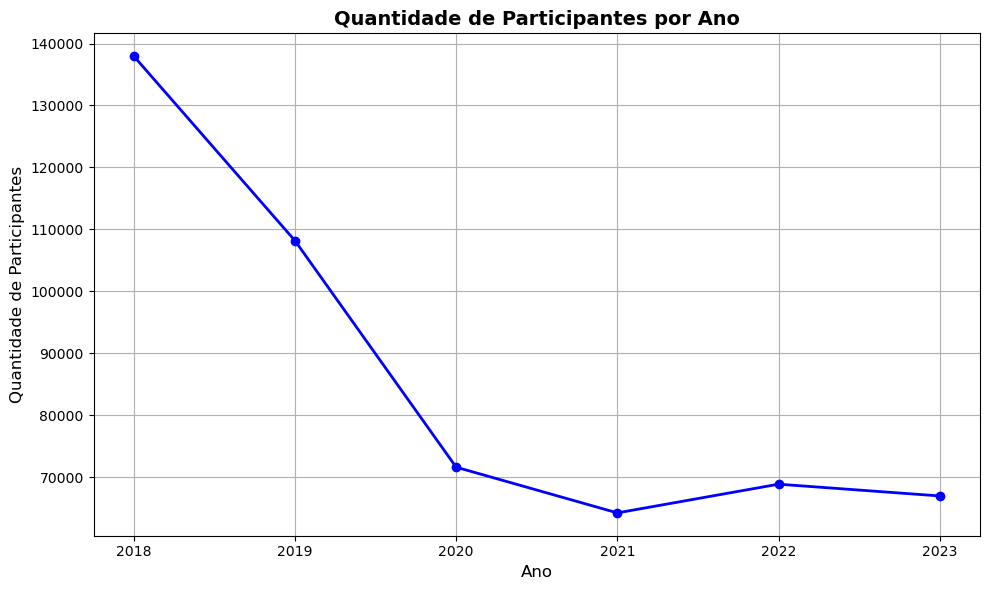

In [11]:
# Agrupar por ano e contar participantes
qtd_por_ano = df_mg.groupby("NU_ANO").size().reset_index(name="Quantidade de Participantes")

qtd_por_ano

plt.figure(figsize=(10,6))
plt.plot(qtd_por_ano["NU_ANO"], qtd_por_ano["Quantidade de Participantes"], 
         marker='o', color='blue', linewidth=2)

plt.title("Quantidade de Participantes por Ano", fontsize=14, fontweight='bold')
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Quantidade de Participantes", fontsize=12)
plt.grid(True)
plt.tight_layout()

### Olhando para as escolas - IFNMG

In [12]:
# Dicionário de mapeamento
mapa_escola = {
    1: "Não Informado",
    2: "Pública",
    3: "Exterior",
    4: "Privada"
}

# Substituir códigos pelos nomes
df_final["TP_ESCOLA"] = df_final["TP_ESCOLA"].map(mapa_escola)

# Contar quantidade por tipo de escola
qtd_escola = df_final["TP_ESCOLA"].value_counts().reindex(mapa_escola.values(), fill_value=0)

porcent_escola = (qtd_escola / qtd_escola.sum() * 100).round(2).astype(str) + "%"

# Criar DataFrame final
tabela = pd.DataFrame([qtd_escola, porcent_escola], index=["Quantidade", "Porcentagem"])

tabela

TP_ESCOLA,Não Informado,Pública,Exterior,Privada
Quantidade,736,52538,4624,1856
Porcentagem,1.23%,87.92%,7.74%,3.11%


### Olhando para as escolas - MG

In [13]:
# Dicionário de mapeamento
mapa_escola = {
    1: "Não Informado",
    2: "Pública",
    3: "Exterior",
    4: "Privada"
}

# Substituir códigos pelos nomes
df_mg["TP_ESCOLA"] = df_mg["TP_ESCOLA"].map(mapa_escola)

# Contar quantidade por tipo de escola
qtd_escola = df_mg["TP_ESCOLA"].value_counts().reindex(mapa_escola.values(), fill_value=0)

porcent_escola = (qtd_escola / qtd_escola.sum() * 100).round(2).astype(str) + "%"

# Criar DataFrame final
tabela = pd.DataFrame([qtd_escola, porcent_escola], index=["Quantidade", "Porcentagem"])

tabela

TP_ESCOLA,Não Informado,Pública,Exterior,Privada
Quantidade,5748,418193,72355,21531
Porcentagem,1.11%,80.76%,13.97%,4.16%


### Olhando por sexo no decorrer do anos - IFNMF

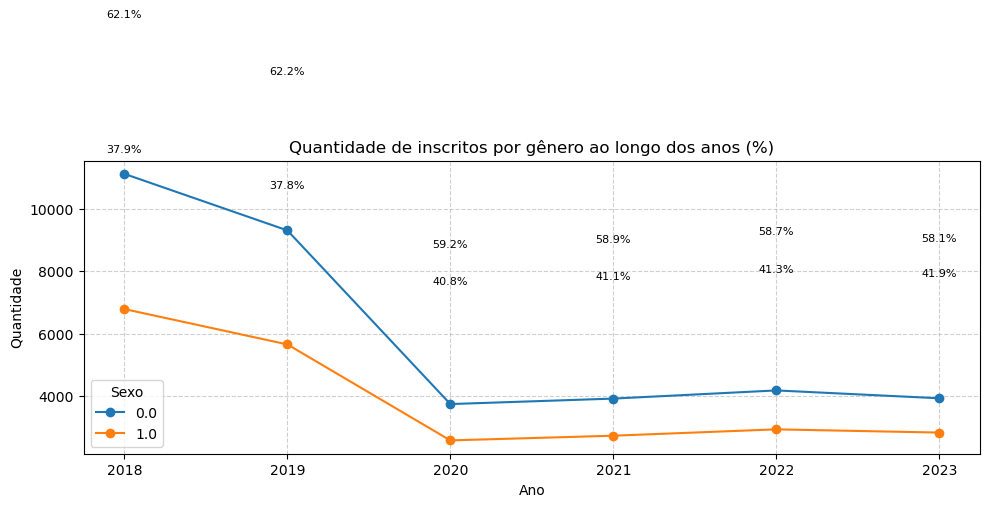

In [15]:
# Agrupar por ano e sexo (F, M)
df_grouped = df_final.groupby(["NU_ANO", "TP_SEXO"]).size().reset_index(name="Quantidade")

# Calcular o total de inscritos por ano
totais_ano = df_grouped.groupby("NU_ANO")["Quantidade"].transform("sum")

# Calcular percentual
df_grouped["Percentual"] = (df_grouped["Quantidade"] / totais_ano) * 100

# Plot
plt.figure(figsize=(10,6))
for sexo in df_grouped["TP_SEXO"].unique():
    subset = df_grouped[df_grouped["TP_SEXO"] == sexo]
    plt.plot(subset["NU_ANO"], subset["Quantidade"], marker="o", label=sexo)
    # Adicionar porcentagem acima dos pontos
    for x, y, p in zip(subset["NU_ANO"], subset["Quantidade"], subset["Percentual"]):
        plt.text(x, y+5000, f"{p:.1f}%", ha="center", fontsize=8)

plt.xlabel("Ano")
plt.ylabel("Quantidade")
plt.title("Quantidade de inscritos por gênero ao longo dos anos (%)")
plt.legend(title="Sexo")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Olhando por sexo no decorrer do anos - MG

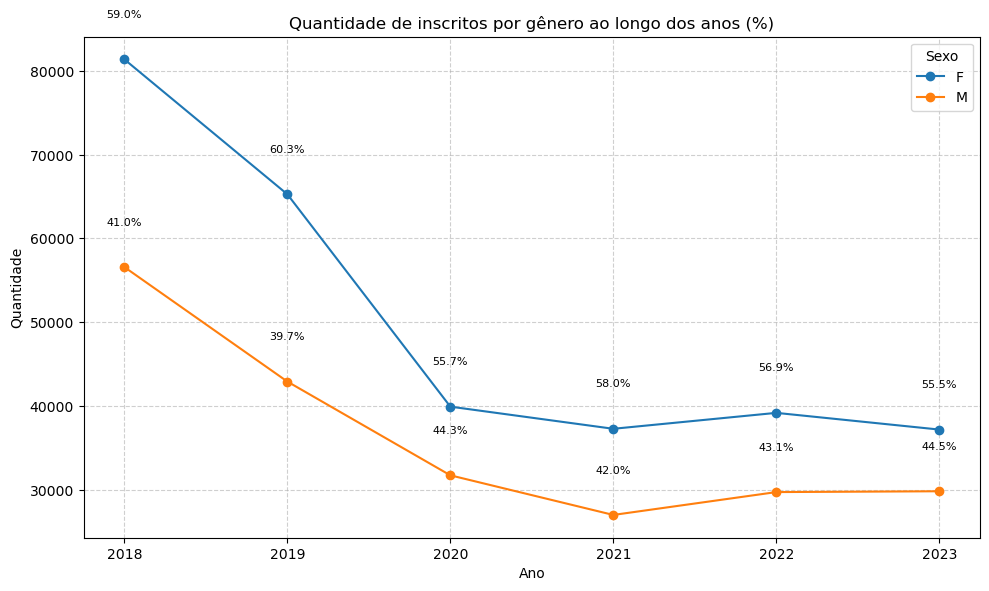

In [16]:
# Agrupar por ano e sexo (F, M)
df_grouped = df_mg.groupby(["NU_ANO", "TP_SEXO"]).size().reset_index(name="Quantidade")

# Calcular o total de inscritos por ano
totais_ano = df_grouped.groupby("NU_ANO")["Quantidade"].transform("sum")

# Calcular percentual
df_grouped["Percentual"] = (df_grouped["Quantidade"] / totais_ano) * 100

# Plot
plt.figure(figsize=(10,6))
for sexo in df_grouped["TP_SEXO"].unique():
    subset = df_grouped[df_grouped["TP_SEXO"] == sexo]
    plt.plot(subset["NU_ANO"], subset["Quantidade"], marker="o", label=sexo)
    # Adicionar porcentagem acima dos pontos
    for x, y, p in zip(subset["NU_ANO"], subset["Quantidade"], subset["Percentual"]):
        plt.text(x, y+5000, f"{p:.1f}%", ha="center", fontsize=8)

plt.xlabel("Ano")
plt.ylabel("Quantidade")
plt.title("Quantidade de inscritos por gênero ao longo dos anos (%)")
plt.legend(title="Sexo")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Quantidade de ocorrências por cada item - IFNMG

In [18]:
variaveis = [
    "TP_SEXO", "TP_ESTADO_CIVIL", "TP_COR_RACA", "TP_NACIONALIDADE",
    "TP_ST_CONCLUSAO", "TP_ESCOLA", "TP_ENSINO", "TP_DEPENDENCIA_ADM_ESC",
    "TP_LOCALIZACAO_ESC", "TP_SIT_FUNC_ESC", "TP_PRESENCA_CN",
    "TP_PRESENCA_CH", "TP_PRESENCA_LC", "TP_PRESENCA_MT",
    "TP_LINGUA", "TP_STATUS_REDACAO",
    "EMP_DOMESTICO", "BANHEIRO", "QTD_QUARTOS", "CARRO", "MOTO",
    "GELADEIRA", "FREEZER", "LAVA_ROUPA", "SECA_ROUPA", "MICROONDAS",
    "LAVA_LOUCA", "ASPIRADOR", "TV", "DVD", "TV_ASSINATURA",
    "CELULAR", "TELEFONE_FIXO", "COMPUTADOR", "INTERNET"
]


# Loop para mostrar as frequências de cada variável
for col in variaveis:
    print(f"\n📌 Coluna: {col}")
    print(df_final[col].value_counts(dropna=False))  # dropna=False inclui valores NaN se existirem


📌 Coluna: TP_SEXO
TP_SEXO
0.0    36203
1.0    23551
Name: count, dtype: int64

📌 Coluna: TP_ESTADO_CIVIL
TP_ESTADO_CIVIL
1.0    40490
0.0    18430
NaN      292
2.0      292
3.0      245
4.0        5
Name: count, dtype: int64

📌 Coluna: TP_COR_RACA
TP_COR_RACA
3    34950
1    14160
2     8111
4     1338
0      877
5      318
Name: count, dtype: int64

📌 Coluna: TP_NACIONALIDADE
TP_NACIONALIDADE
1    57613
2     1916
4      144
0       49
3       32
Name: count, dtype: int64

📌 Coluna: TP_ST_CONCLUSAO
TP_ST_CONCLUSAO
2    59754
Name: count, dtype: int64

📌 Coluna: TP_ESCOLA
TP_ESCOLA
Pública          52538
Exterior          4624
Privada           1856
Não Informado      736
Name: count, dtype: int64

📌 Coluna: TP_ENSINO
TP_ENSINO
1.0    57424
NaN     1178
3.0      977
2.0      175
Name: count, dtype: int64

📌 Coluna: TP_DEPENDENCIA_ADM_ESC
TP_DEPENDENCIA_ADM_ESC
2.0    46110
4.0     8474
1.0     5118
3.0       52
Name: count, dtype: int64

📌 Coluna: TP_LOCALIZACAO_ESC
TP_LOCALIZACAO_ESC